In [6]:
import ee
import geemap
import numpy as np
import pandas as pd

ee.Initialize(project='wind-field-estimation-497821')

In [7]:
aoi = ee.Geometry.Rectangle([68.0, 21.0, 70.0, 23.0])

In [3]:
dates = [
    '2024-06-01',
    '2024-06-05',
    '2024-06-10',
    '2024-06-15',
    '2024-06-20'
]

In [4]:
results = []

In [7]:
for date in dates:

    print(f"Processing {date}")

    # SAR collection
    sar_collection = (
        ee.ImageCollection('COPERNICUS/S1_GRD')
        .filterBounds(aoi)
        .filterDate(date, ee.Date(date).advance(1, 'day'))
        .filter(ee.Filter.eq('instrumentMode', 'IW'))
        .filter(
            ee.Filter.listContains(
                'transmitterReceiverPolarisation',
                'VV'
            )
        )
        .select('VV')
    )

    count = sar_collection.size().getInfo()

    if count == 0:
        print(f"No SAR image for {date}")
        continue

    sar = sar_collection.first()

    # SAR statistics
    sar_stats = sar.reduceRegion(
        reducer=ee.Reducer.mean().combine(
            reducer2=ee.Reducer.stdDev(),
            sharedInputs=True
        ),
        geometry=aoi,
        scale=100,
        maxPixels=1e9
    ).getInfo()

    # ERA5
    era5 = (
        ee.ImageCollection('ECMWF/ERA5_LAND/HOURLY')
        .filterBounds(aoi)
        .filterDate(date, ee.Date(date).advance(1, 'day'))
        .select([
            'u_component_of_wind_10m',
            'v_component_of_wind_10m'
        ])
        .first()
    )

    u = era5.select('u_component_of_wind_10m')
    v = era5.select('v_component_of_wind_10m')

    wind_speed = u.pow(2).add(v.pow(2)).sqrt()

    wind_stats = wind_speed.reduceRegion(
        reducer=ee.Reducer.mean(),
        geometry=aoi,
        scale=10000,
        maxPixels=1e9
    ).getInfo()

    results.append({
        'date': date,
        'sar_mean': sar_stats.get('VV_mean'),
        'sar_std': sar_stats.get('VV_stdDev'),
        'wind_speed': list(wind_stats.values())[0]
    })

print("Done")

Processing 2024-06-01
No SAR image for 2024-06-01
Processing 2024-06-05
Processing 2024-06-10
Processing 2024-06-15
Processing 2024-06-20
No SAR image for 2024-06-20
Done


In [8]:
df = pd.DataFrame(results)

df

,date,sar_mean,sar_std,wind_speed
0,2024-06-05,-17.227082,1.493565,4.114371
1,2024-06-10,-12.858425,2.436630,4.157246
2,2024-06-15,-17.103690,4.350845,3.923042


In [10]:
print(df.corr(numeric_only=True))

            sar_mean   sar_std  wind_speed
sar_mean    1.000000 -0.168162    0.622213
sar_std    -0.168162  1.000000   -0.876332
wind_speed  0.622213 -0.876332    1.000000


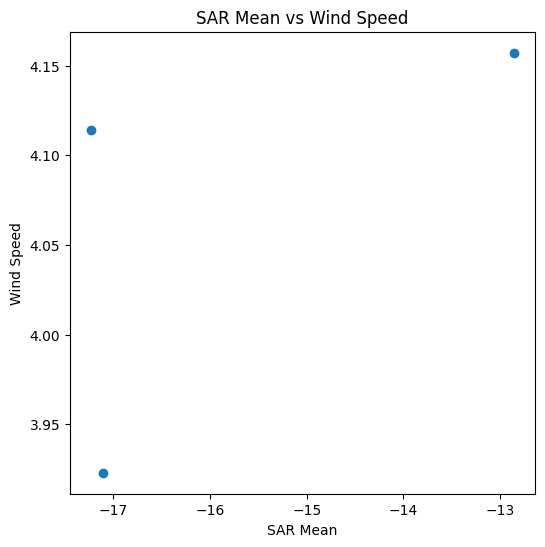

In [11]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6,6))

plt.scatter(df['sar_mean'], df['wind_speed'])

plt.xlabel("SAR Mean")
plt.ylabel("Wind Speed")

plt.title("SAR Mean vs Wind Speed")

plt.show()

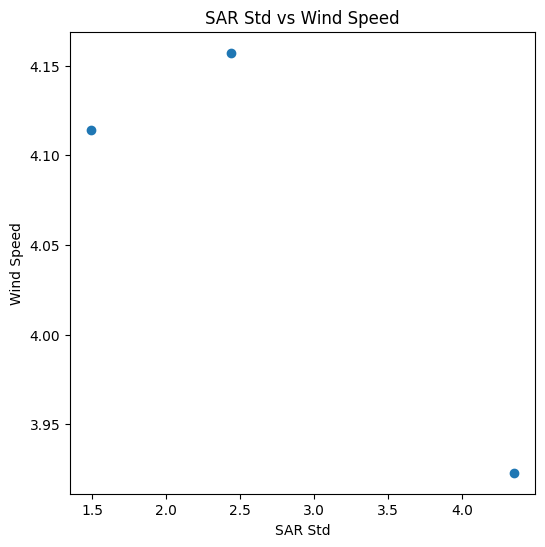

In [12]:
plt.figure(figsize=(6,6))

plt.scatter(df['sar_std'], df['wind_speed'])

plt.xlabel("SAR Std")
plt.ylabel("Wind Speed")

plt.title("SAR Std vs Wind Speed")

plt.show()

In [13]:
dates = pd.date_range(
    start='2024-01-01',
    end='2024-03-31',
    freq='5D'
)

dates = [d.strftime('%Y-%m-%d') for d in dates]

print(dates)

['2024-01-01', '2024-01-06', '2024-01-11', '2024-01-16', '2024-01-21', '2024-01-26', '2024-01-31', '2024-02-05', '2024-02-10', '2024-02-15', '2024-02-20', '2024-02-25', '2024-03-01', '2024-03-06', '2024-03-11', '2024-03-16', '2024-03-21', '2024-03-26', '2024-03-31']


In [14]:
for date in dates:

    print(f"Processing {date}")

    # SAR collection
    sar_collection = (
        ee.ImageCollection('COPERNICUS/S1_GRD')
        .filterBounds(aoi)
        .filterDate(date, ee.Date(date).advance(1, 'day'))
        .filter(ee.Filter.eq('instrumentMode', 'IW'))
        .filter(
            ee.Filter.listContains(
                'transmitterReceiverPolarisation',
                'VV'
            )
        )
        .select('VV')
    )

    count = sar_collection.size().getInfo()

    if count == 0:
        print(f"No SAR image for {date}")
        continue

    sar = sar_collection.first()

    # SAR statistics
    sar_stats = sar.reduceRegion(
        reducer=ee.Reducer.mean().combine(
            reducer2=ee.Reducer.stdDev(),
            sharedInputs=True
        ),
        geometry=aoi,
        scale=100,
        maxPixels=1e9
    ).getInfo()

    # ERA5
    era5 = (
        ee.ImageCollection('ECMWF/ERA5_LAND/HOURLY')
        .filterBounds(aoi)
        .filterDate(date, ee.Date(date).advance(1, 'day'))
        .select([
            'u_component_of_wind_10m',
            'v_component_of_wind_10m'
        ])
        .first()
    )

    u = era5.select('u_component_of_wind_10m')
    v = era5.select('v_component_of_wind_10m')

    wind_speed = u.pow(2).add(v.pow(2)).sqrt()

    wind_stats = wind_speed.reduceRegion(
        reducer=ee.Reducer.mean(),
        geometry=aoi,
        scale=10000,
        maxPixels=1e9
    ).getInfo()

    results.append({
        'date': date,
        'sar_mean': sar_stats.get('VV_mean'),
        'sar_std': sar_stats.get('VV_stdDev'),
        'wind_speed': list(wind_stats.values())[0]
    })

print("Done")

Processing 2024-01-01
Processing 2024-01-06
Processing 2024-01-11
Processing 2024-01-16
No SAR image for 2024-01-16
Processing 2024-01-21
No SAR image for 2024-01-21
Processing 2024-01-26
No SAR image for 2024-01-26
Processing 2024-01-31
No SAR image for 2024-01-31
Processing 2024-02-05
No SAR image for 2024-02-05
Processing 2024-02-10
No SAR image for 2024-02-10
Processing 2024-02-15
No SAR image for 2024-02-15
Processing 2024-02-20
No SAR image for 2024-02-20
Processing 2024-02-25
No SAR image for 2024-02-25
Processing 2024-03-01
Processing 2024-03-06
No SAR image for 2024-03-06
Processing 2024-03-11
Processing 2024-03-16
No SAR image for 2024-03-16
Processing 2024-03-21
No SAR image for 2024-03-21
Processing 2024-03-26
No SAR image for 2024-03-26
Processing 2024-03-31
No SAR image for 2024-03-31
Done


In [15]:
df = pd.DataFrame(results)

df

,date,sar_mean,sar_std,wind_speed
0,2024-06-05,-17.227082,1.493565,4.114371
1,2024-06-10,-12.858425,2.436630,4.157246
2,2024-06-15,-17.103690,4.350845,3.923042
3,2024-01-01,-20.350942,2.539812,4.015245
4,2024-01-06,-12.849662,3.116582,4.282538
5,2024-01-11,-17.677351,4.747860,4.561932
6,2024-03-01,-24.352950,6.625076,3.204917
7,2024-03-11,-18.509386,5.378033,2.930705


In [16]:
results = []

for date in dates:

    try:

        print(f"Processing {date}")

        # SAR collection
        sar_collection = (
            ee.ImageCollection('COPERNICUS/S1_GRD')
            .filterBounds(aoi)
            .filterDate(date, ee.Date(date).advance(1, 'day'))
            .filter(ee.Filter.eq('instrumentMode', 'IW'))
            .filter(
                ee.Filter.listContains(
                    'transmitterReceiverPolarisation',
                    'VV'
                )
            )
            .select('VV')
        )

        count = sar_collection.size().getInfo()

        if count == 0:
            print(f"No SAR image for {date}")
            continue

        sar = sar_collection.first()

        sar_stats = sar.reduceRegion(
            reducer=ee.Reducer.mean().combine(
                reducer2=ee.Reducer.stdDev(),
                sharedInputs=True
            ),
            geometry=aoi,
            scale=100,
            maxPixels=1e9
        ).getInfo()

        # ERA5
        era5 = (
            ee.ImageCollection('ECMWF/ERA5_LAND/HOURLY')
            .filterBounds(aoi)
            .filterDate(date, ee.Date(date).advance(1, 'day'))
            .select([
                'u_component_of_wind_10m',
                'v_component_of_wind_10m'
            ])
            .first()
        )

        u = era5.select('u_component_of_wind_10m')
        v = era5.select('v_component_of_wind_10m')

        wind_speed = u.pow(2).add(v.pow(2)).sqrt()

        wind_stats = wind_speed.reduceRegion(
            reducer=ee.Reducer.mean(),
            geometry=aoi,
            scale=10000,
            maxPixels=1e9
        ).getInfo()

        results.append({
            'date': date,
            'sar_mean': sar_stats.get('VV_mean'),
            'sar_std': sar_stats.get('VV_stdDev'),
            'wind_speed': list(wind_stats.values())[0]
        })

    except Exception as e:
        print(f"Error on {date}: {e}")

Processing 2024-01-01
Processing 2024-01-06
Processing 2024-01-11
Processing 2024-01-16
No SAR image for 2024-01-16
Processing 2024-01-21
No SAR image for 2024-01-21
Processing 2024-01-26
No SAR image for 2024-01-26
Processing 2024-01-31
No SAR image for 2024-01-31
Processing 2024-02-05
No SAR image for 2024-02-05
Processing 2024-02-10
No SAR image for 2024-02-10
Processing 2024-02-15
No SAR image for 2024-02-15
Processing 2024-02-20
No SAR image for 2024-02-20
Processing 2024-02-25
No SAR image for 2024-02-25
Processing 2024-03-01
Processing 2024-03-06
No SAR image for 2024-03-06
Processing 2024-03-11
Processing 2024-03-16
No SAR image for 2024-03-16
Processing 2024-03-21
No SAR image for 2024-03-21
Processing 2024-03-26
No SAR image for 2024-03-26
Processing 2024-03-31
No SAR image for 2024-03-31


In [17]:
df = pd.DataFrame(results)

print(df.head())

print("Total samples:", len(df))

         date   sar_mean   sar_std  wind_speed
0  2024-01-01 -20.350942  2.539812    4.015245
1  2024-01-06 -12.849662  3.116582    4.282538
2  2024-01-11 -17.677351  4.747860    4.561932
3  2024-03-01 -24.352950  6.625076    3.204917
4  2024-03-11 -18.509386  5.378033    2.930705
Total samples: 5


we get cleaner samples but we get lesser data, we need to get more

In [18]:
results = []

for date in dates:

    try:

        print(f"Processing {date}")

        # SAR collection
        sar_collection = (
            ee.ImageCollection('COPERNICUS/S1_GRD')
            .filterBounds(aoi)
            .filterDate(date, ee.Date(date).advance(5, 'day'))
            .filter(ee.Filter.eq('instrumentMode', 'IW'))
            .filter(
                ee.Filter.listContains(
                    'transmitterReceiverPolarisation',
                    'VV'
                )
            )
            .select('VV')
        )

        count = sar_collection.size().getInfo()

        if count == 0:
            print(f"No SAR image for {date}")
            continue

        sar = sar_collection.mean()

        sar_stats = sar.reduceRegion(
            reducer=ee.Reducer.mean().combine(
                reducer2=ee.Reducer.stdDev(),
                sharedInputs=True
            ),
            geometry=aoi,
            scale=100,
            maxPixels=1e9
        ).getInfo()

        # ERA5
        era5 = (
            ee.ImageCollection('ECMWF/ERA5_LAND/HOURLY')
            .filterBounds(aoi)
            .filterDate(date, ee.Date(date).advance(5, 'day'))
            .select([
                'u_component_of_wind_10m',
                'v_component_of_wind_10m'
            ])
            .mean()
        )

        u = era5.select('u_component_of_wind_10m')
        v = era5.select('v_component_of_wind_10m')

        wind_speed = u.pow(2).add(v.pow(2)).sqrt()

        wind_stats = wind_speed.reduceRegion(
            reducer=ee.Reducer.mean(),
            geometry=aoi,
            scale=10000,
            maxPixels=1e9
        ).getInfo()

        results.append({
            'date': date,
            'sar_mean': sar_stats.get('VV_mean'),
            'sar_std': sar_stats.get('VV_stdDev'),
            'wind_speed': list(wind_stats.values())[0]
        })

    except Exception as e:
        print(f"Error on {date}: {e}")

Processing 2024-01-01
Processing 2024-01-06
Processing 2024-01-11
Processing 2024-01-16
Processing 2024-01-21
Processing 2024-01-26
Processing 2024-01-31
Processing 2024-02-05
Processing 2024-02-10
Processing 2024-02-15
Processing 2024-02-20
Processing 2024-02-25
Processing 2024-03-01
Processing 2024-03-06
No SAR image for 2024-03-06
Processing 2024-03-11
Processing 2024-03-16
No SAR image for 2024-03-16
Processing 2024-03-21
Processing 2024-03-26
Processing 2024-03-31


In [19]:
df = pd.DataFrame(results)

print(df.head())

print("Total samples:", len(df))

         date   sar_mean   sar_std  wind_speed
0  2024-01-01 -20.350079  2.540037    3.957147
1  2024-01-06 -15.980953  5.044626    5.572752
2  2024-01-11 -17.652568  4.025208    2.733928
3  2024-01-16 -16.387877  5.698650    2.581052
4  2024-01-21 -18.639536  4.509222    2.395798
Total samples: 17


In [20]:
print(df.corr(numeric_only=True))

            sar_mean   sar_std  wind_speed
sar_mean    1.000000 -0.342457    0.211824
sar_std    -0.342457  1.000000   -0.219523
wind_speed  0.211824 -0.219523    1.000000


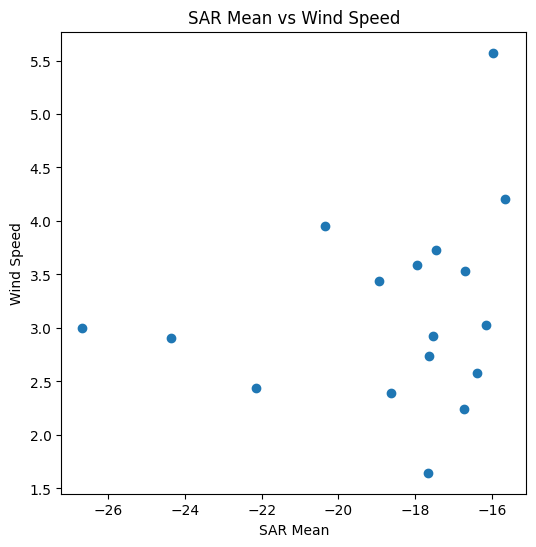

In [21]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6,6))

plt.scatter(df['sar_mean'], df['wind_speed'])

plt.xlabel("SAR Mean")
plt.ylabel("Wind Speed")

plt.title("SAR Mean vs Wind Speed")

plt.show()

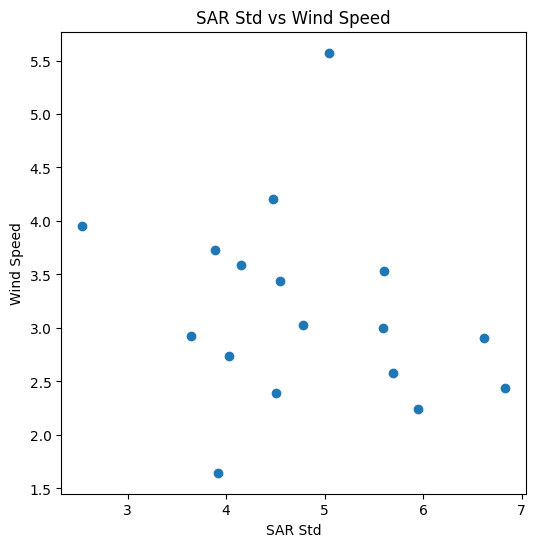

In [22]:
plt.figure(figsize=(6,6))

plt.scatter(df['sar_std'], df['wind_speed'])

plt.xlabel("SAR Std")
plt.ylabel("Wind Speed")

plt.title("SAR Std vs Wind Speed")

plt.show()

basic mean and std arent giving any significant observation, so we need more factors

In [23]:
from scipy.ndimage import gaussian_filter
from scipy.ndimage import generic_filter

In [3]:
import pandas as pd

In [8]:
dates = pd.date_range(
    start='2024-01-01',
    end='2024-03-31',
    freq='5D'
)

dates = [d.strftime('%Y-%m-%d') for d in dates]

print(dates)

['2024-01-01', '2024-01-06', '2024-01-11', '2024-01-16', '2024-01-21', '2024-01-26', '2024-01-31', '2024-02-05', '2024-02-10', '2024-02-15', '2024-02-20', '2024-02-25', '2024-03-01', '2024-03-06', '2024-03-11', '2024-03-16', '2024-03-21', '2024-03-26', '2024-03-31']


In [9]:
results = []

for date in dates:

    try:

        print(f"Processing {date}")

        # SAR collection
        sar_collection = (
            ee.ImageCollection('COPERNICUS/S1_GRD')
            .filterBounds(aoi)
            .filterDate(date, ee.Date(date).advance(5, 'day'))
            .filter(ee.Filter.eq('instrumentMode', 'IW'))
            .filter(
                ee.Filter.listContains(
                    'transmitterReceiverPolarisation',
                    'VV'
                )
            )
            .select('VV')
        )

        count = sar_collection.size().getInfo()

        if count == 0:
            print(f"No SAR image for {date}")
            continue

        sar = sar_collection.mean()

        sar_stats = sar.reduceRegion(
            reducer=(
                ee.Reducer.mean()
                .combine(
                    reducer2=ee.Reducer.stdDev(),
                    sharedInputs=True
                )
                .combine(
                    reducer2=ee.Reducer.percentile([25, 50, 75]),
                    sharedInputs=True
                )
            ),
            geometry=aoi,
            scale=100,
            maxPixels=1e9
        ).getInfo()

        # ERA5
        era5 = (
            ee.ImageCollection('ECMWF/ERA5_LAND/HOURLY')
            .filterBounds(aoi)
            .filterDate(date, ee.Date(date).advance(5, 'day'))
            .select([
                'u_component_of_wind_10m',
                'v_component_of_wind_10m'
            ])
            .mean()
        )

        u = era5.select('u_component_of_wind_10m')
        v = era5.select('v_component_of_wind_10m')

        wind_speed = u.pow(2).add(v.pow(2)).sqrt()

        wind_stats = wind_speed.reduceRegion(
            reducer=ee.Reducer.mean(),
            geometry=aoi,
            scale=10000,
            maxPixels=1e9
        ).getInfo()

        results.append({
            'date': date,
            'sar_mean': sar_stats.get('VV_mean'),
            'sar_std': sar_stats.get('VV_stdDev'),
            'sar_p25': sar_stats.get('VV_p25'),
            'sar_p50': sar_stats.get('VV_p50'),
            'sar_p75': sar_stats.get('VV_p75'),
            'wind_speed': list(wind_stats.values())[0]
        })

    except Exception as e:
        print(f"Error on {date}: {e}")

Processing 2024-01-01
Processing 2024-01-06
Processing 2024-01-11
Processing 2024-01-16
Processing 2024-01-21
Processing 2024-01-26
Processing 2024-01-31
Processing 2024-02-05
Processing 2024-02-10
Processing 2024-02-15
Processing 2024-02-20
Processing 2024-02-25
Processing 2024-03-01
Processing 2024-03-06
No SAR image for 2024-03-06
Processing 2024-03-11
Processing 2024-03-16
No SAR image for 2024-03-16
Processing 2024-03-21
Processing 2024-03-26
Processing 2024-03-31


In [10]:
df = pd.DataFrame(results)

print(df.head())

print("Samples:", len(df))

         date   sar_mean   sar_std    sar_p25    sar_p50    sar_p75  \
0  2024-01-01 -20.350079  2.540037 -21.876214 -20.123705 -19.376360   
1  2024-01-06 -15.980953  5.044626 -21.751096 -13.739623 -11.752321   
2  2024-01-11 -17.652568  4.025208 -20.245590 -18.752682 -15.761586   
3  2024-01-16 -16.387877  5.698650 -22.759828 -13.738915 -11.755230   
4  2024-01-21 -18.639536  4.509222 -21.623835 -20.126444 -17.128419   

   wind_speed  
0    3.957147  
1    5.572752  
2    2.733928  
3    2.581052  
4    2.395798  
Samples: 17


In [11]:
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error

In [12]:
X = df[[
    'sar_mean',
    'sar_std',
    'sar_p25',
    'sar_p50',
    'sar_p75'
]]

y = df['wind_speed']

In [13]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.3,
    random_state=42
)

In [14]:
model = LinearRegression()

model.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [15]:
predictions = model.predict(X_test)

print(predictions)

[2.46590266 2.94131617 3.03011874 2.54989898 2.8162819  2.93619635]


In [16]:
mae = mean_absolute_error(
    y_test,
    predictions
)

print("MAE:", mae)

MAE: 1.220708277047131


In [17]:
comparison = pd.DataFrame({
    'Actual': y_test.values,
    'Predicted': predictions
})

print(comparison)

     Actual  Predicted
0  3.957147   2.465903
1  5.572752   2.941316
2  2.241641   3.030119
3  4.205434   2.549899
4  2.924787   2.816282
5  3.585249   2.936196


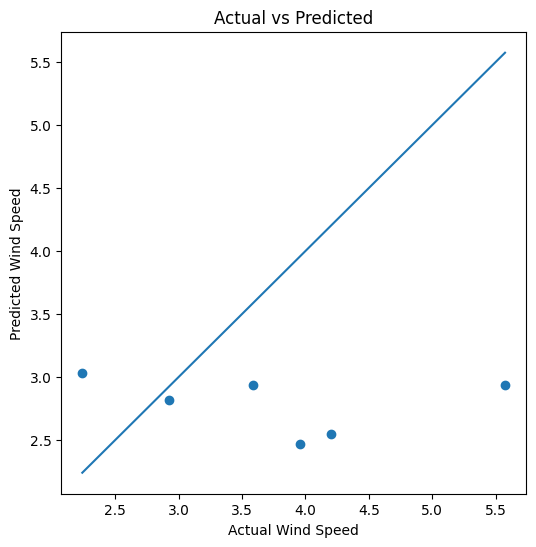

In [18]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6,6))

plt.scatter(
    y_test,
    predictions
)

plt.xlabel("Actual Wind Speed")
plt.ylabel("Predicted Wind Speed")

plt.title("Actual vs Predicted")

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()]
)

plt.show()

In [19]:
feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': model.coef_
})

print(feature_importance)

    Feature  Coefficient
0  sar_mean     0.773871
1   sar_std    -0.104309
2   sar_p25    -0.443973
3   sar_p50    -0.108648
4   sar_p75    -0.248597


In [20]:
from sklearn.ensemble import RandomForestRegressor

In [21]:
rf_model = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

rf_model.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""squared_error"", ""absolute_error"", ""friedman_mse"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in Poisson deviance to find splits.Training using ""absolute_error"" is significantly slowerthan when using ""squared_error""... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsample

In [22]:
rf_predictions = rf_model.predict(X_test)

In [23]:
rf_mae = mean_absolute_error(
    y_test,
    rf_predictions
)

print("Random Forest MAE:", rf_mae)

Random Forest MAE: 1.1444759657100514


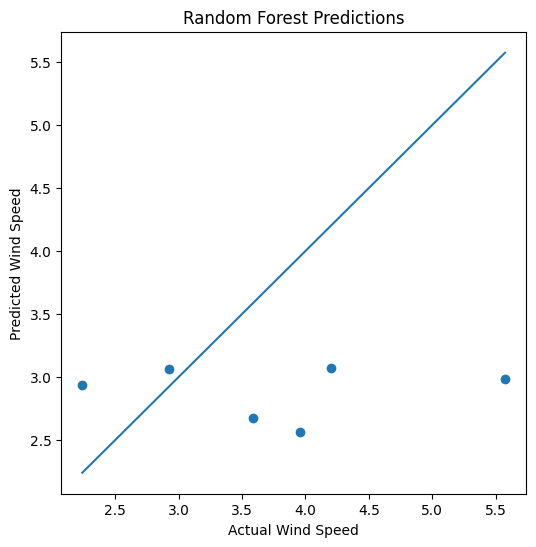

In [24]:
plt.figure(figsize=(6,6))

plt.scatter(
    y_test,
    rf_predictions
)

plt.xlabel("Actual Wind Speed")
plt.ylabel("Predicted Wind Speed")

plt.title("Random Forest Predictions")

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()]
)

plt.show()

In [26]:
#have to save the model now
import joblib

joblib.dump(
    rf_model,
    '../models/random_forest_model.pkl'
)

print("Random Forest model saved successfully")

Random Forest model saved successfully


In [27]:
loaded_model = joblib.load(
    '../models/random_forest_model.pkl'
)

print("Model loaded successfully")

Model loaded successfully


In [28]:
sample = [[
    -21.9,
    0.55,
    -22.3,
    -21.9,
    -21.5
]]

prediction = loaded_model.predict(sample)

print(prediction)

[2.5475402]


c:\Users\skull\Desktop\padhai\web development\phase 2\projects3\wind-field-estimation\venv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  warnings.warn(
